In [1]:
# Import libraries and setup
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Cell 1: Import libraries and setup
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

print("Libraries imported successfully!")

# %%
# Cell 2: Define SimpleGridWorld class
class SimpleGridWorld:
    """Simple 3x3 GridWorld for TD(0) demonstration"""
    
    def __init__(self):
        self.size = 3
        self.num_states = self.size * self.size
        self.num_actions = 4
        self.actions = ['up', 'down', 'left', 'right']
        
        # State mapping: (row, col) -> state_id
        self.state_to_id = {(i, j): i * self.size + j for i in range(self.size) for j in range(self.size)}
        self.id_to_state = {v: k for k, v in self.state_to_id.items()}
        
        # Terminal states
        self.terminal_states = [0, 8]  # Top-left and bottom-right corners
        
        # Current state for episode simulation
        self.current_state = None
        
        self._build_rewards()
    
    def _build_rewards(self):
        """Build reward structure"""
        self.rewards = {}
        for s in range(self.num_states):
            if s == 0:  # Top-left terminal state (bad outcome)
                self.rewards[s] = -10
            elif s == 8:  # Bottom-right terminal state (good outcome)
                self.rewards[s] = 10
            else:  # All other states
                self.rewards[s] = -1  # Small negative reward to encourage finding terminal states quickly
    
    def reset(self):
        """Reset environment to a random non-terminal state"""
        non_terminal_states = [s for s in range(self.num_states) if s not in self.terminal_states]
        self.current_state = random.choice(non_terminal_states)
        return self.current_state
    
    def step(self, action):
        """Take an action and return next_state, reward, done"""
        if self.current_state in self.terminal_states:
            return self.current_state, 0, True
        
        # Get current position
        row, col = self.id_to_state[self.current_state]
        
        # Apply action
        if action == 0:  # up
            new_row = max(0, row - 1)
            new_col = col
        elif action == 1:  # down
            new_row = min(self.size - 1, row + 1)
            new_col = col
        elif action == 2:  # left
            new_row = row
            new_col = max(0, col - 1)
        elif action == 3:  # right
            new_row = row
            new_col = min(self.size - 1, col + 1)
        
        # Get new state
        next_state = self.state_to_id[(new_row, new_col)]
        
        # Get reward
        reward = self.rewards[next_state]
        
        # Check if terminal
        done = next_state in self.terminal_states
        
        # Update current state
        self.current_state = next_state
        
        return next_state, reward, done
    
    def is_terminal(self, state):
        """Check if state is terminal"""
        return state in self.terminal_states
    
    def print_grid(self, values=None):
        """Print the grid world with optional values"""
        print("\nGrid Layout:")
        print("States: T = Terminal, numbers = state IDs")
        for i in range(self.size):
            row_str = ""
            for j in range(self.size):
                state_id = self.state_to_id[(i, j)]
                if state_id in self.terminal_states:
                    if state_id == 0:
                        row_str += " T- "  # Bad terminal
                    else:
                        row_str += " T+ "  # Good terminal
                else:
                    row_str += f" {state_id:2d} "
            print(row_str)
        
        if values is not None:
            print("\nState Values:")
            for i in range(self.size):
                row_str = ""
                for j in range(self.size):
                    state_id = self.state_to_id[(i, j)]
                    row_str += f"{values[state_id]:6.2f} "
                print(row_str)

print("SimpleGridWorld class defined!")

Libraries imported successfully!
SimpleGridWorld class defined!


In [6]:
# Cell 3: Test the environment
env = SimpleGridWorld()
env.print_grid()

print(f"\nEnvironment details:")
print(f"Grid size: {env.size}x{env.size}")
print(f"Number of states: {env.num_states}")
print(f"Actions: {env.actions}")
print(f"Terminal states: {env.terminal_states}")
print(f"Rewards: {env.rewards}")



Grid Layout:
States: T = Terminal, numbers = state IDs
 T-   1   2 
  3   4   5 
  6   7  T+ 

Environment details:
Grid size: 3x3
Number of states: 9
Actions: ['up', 'down', 'left', 'right']
Terminal states: [0, 8]
Rewards: {0: -10, 1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: 10}


In [7]:

# Cell 4: Test environment interaction
print("Testing environment interaction:")
state = env.reset()
print(f"Initial state: {state} at position {env.id_to_state[state]}")

for step in range(5):
    action = random.randint(0, 3)
    next_state, reward, done = env.step(action)
    print(f"Step {step+1}: Action {env.actions[action]} -> State {next_state} "
          f"at {env.id_to_state[next_state]}, Reward: {reward}, Done: {done}")
    if done:
        print("Episode finished!")
        break

Testing environment interaction:
Initial state: 2 at position (0, 2)
Step 1: Action left -> State 1 at (0, 1), Reward: -1, Done: False
Step 2: Action right -> State 2 at (0, 2), Reward: -1, Done: False
Step 3: Action right -> State 2 at (0, 2), Reward: -1, Done: False
Step 4: Action left -> State 1 at (0, 1), Reward: -1, Done: False
Step 5: Action left -> State 0 at (0, 0), Reward: -10, Done: True
Episode finished!


In [8]:
# Cell 5: Define TD(0) Agent class
class TD0Agent:
    """TD(0) Learning Agent"""
    
    def __init__(self, num_states, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        
        # Initialize state values
        self.V = np.zeros(num_states)
        
        # Simple policy: random action selection with some preference
        self.policy = np.ones((num_states, num_actions)) / num_actions
    
    def select_action(self, state):
        """Select action using epsilon-greedy policy"""
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        else:
            # Choose action based on simple heuristic (move towards bottom-right)
            return self._greedy_action(state)
    
    def _greedy_action(self, state):
        """Simple greedy action selection (heuristic-based)"""
        # This is a simple heuristic: try to move towards state 8 (bottom-right)
        if state < 6:  # Not in bottom row
            return 1  # down
        elif state % 3 < 2:  # Not in rightmost column
            return 3  # right
        else:
            return random.randint(0, self.num_actions - 1)  # random if stuck
    
    def td0_update(self, state, reward, next_state, done):
        """Perform TD(0) update"""
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.V[next_state]
        
        td_error = td_target - self.V[state]
        self.V[state] += self.alpha * td_error
        
        return td_error
    
    def get_value_function(self):
        """Return current value function"""
        return self.V.copy()

print("TD0Agent class defined!")

TD0Agent class defined!


In [9]:
# Cell 6: Create and initialize agent
agent = TD0Agent(
    num_states=env.num_states,
    num_actions=env.num_actions,
    alpha=0.1,    # Learning rate
    gamma=0.9,    # Discount factor
    epsilon=0.1   # Exploration rate
)

print("Agent created with parameters:")
print(f"Learning rate (alpha): {agent.alpha}")
print(f"Discount factor (gamma): {agent.gamma}")
print(f"Exploration rate (epsilon): {agent.epsilon}")
print(f"Initial value function: {agent.V}")


Agent created with parameters:
Learning rate (alpha): 0.1
Discount factor (gamma): 0.9
Exploration rate (epsilon): 0.1
Initial value function: [0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:

# Cell 7: Run a single episode to see TD(0) in action
print("Running a single episode step-by-step:")
state = env.reset()
print(f"Starting state: {state}")

episode_reward = 0
step_count = 0
max_steps = 20

while step_count < max_steps:
    print(f"\nStep {step_count + 1}:")
    print(f"Current state: {state}, Value: {agent.V[state]:.3f}")
    
    action = agent.select_action(state)
    print(f"Selected action: {env.actions[action]}")
    
    next_state, reward, done = env.step(action)
    print(f"Next state: {next_state}, Reward: {reward}, Done: {done}")
    
    # Show value before update
    old_value = agent.V[state]
    
    # Perform TD(0) update
    td_error = agent.td0_update(state, reward, next_state, done)
    
    # Show value after update
    new_value = agent.V[state]
    print(f"Value update: {old_value:.3f} -> {new_value:.3f} (TD error: {td_error:.3f})")
    
    episode_reward += reward
    state = next_state
    step_count += 1
    
    if done:
        print(f"\nEpisode finished! Total reward: {episode_reward}")
        break


Running a single episode step-by-step:
Starting state: 5

Step 1:
Current state: 5, Value: 0.000
Selected action: down
Next state: 8, Reward: 10, Done: True
Value update: 0.000 -> 1.000 (TD error: 10.000)

Episode finished! Total reward: 10


In [11]:
# Cell 8: Define training function
def run_td0_learning(env, agent, episodes=1000, verbose=True):
    """Run TD(0) learning algorithm"""
    
    # Track learning progress
    episode_rewards = []
    value_history = []
    td_errors = []
    
    if verbose:
        print("Starting TD(0) Learning...")
        print(f"Parameters: alpha={agent.alpha}, gamma={agent.gamma}, epsilon={agent.epsilon}")
    
    for episode in range(episodes):
        state = env.reset()
        episode_reward = 0
        episode_td_errors = []
        step_count = 0
        max_steps = 50  # Prevent infinite loops
        
        while step_count < max_steps:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            
            # Perform TD(0) update
            td_error = agent.td0_update(state, reward, next_state, done)
            episode_td_errors.append(abs(td_error))
            
            episode_reward += reward
            state = next_state
            step_count += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        td_errors.append(np.mean(episode_td_errors))
        
        # Store value function periodically
        if episode % 100 == 0:
            value_history.append(agent.get_value_function())
            if verbose and episode % 200 == 0:
                print(f"Episode {episode}: Avg Reward = {np.mean(episode_rewards[-100:]):.2f}, "
                      f"Avg TD Error = {np.mean(td_errors[-100:]):.4f}")
    
    return episode_rewards, value_history, td_errors

print("Training function defined!")

Training function defined!


In [12]:
# Cell 9: Train the agent
# Reset agent for fresh training
agent = TD0Agent(env.num_states, env.num_actions, alpha=0.1, gamma=0.9, epsilon=0.1)

print("Training agent...")
episode_rewards, value_history, td_errors = run_td0_learning(
    env, agent, episodes=1000, verbose=True
)

print("Training completed!")
print(f"Total episodes: {len(episode_rewards)}")
print(f"Final average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")


Training agent...
Starting TD(0) Learning...
Parameters: alpha=0.1, gamma=0.9, epsilon=0.1
Episode 0: Avg Reward = 8.00, Avg TD Error = 4.0000
Episode 200: Avg Reward = 8.35, Avg TD Error = 0.9615
Episode 400: Avg Reward = 8.74, Avg TD Error = 0.4588
Episode 600: Avg Reward = 7.83, Avg TD Error = 1.2439
Episode 800: Avg Reward = 8.28, Avg TD Error = 0.9279
Training completed!
Total episodes: 1000
Final average reward (last 100 episodes): 8.55



Grid Layout:
States: T = Terminal, numbers = state IDs
 T-   1   2 
  3   4   5 
  6   7  T+ 

State Values:
  0.00   5.62   7.68 
  4.76   7.53   9.79 
  7.33   9.66   0.00 

Final Value Function:
State -> Value
State 0 (0, 0): 0.000 (TERMINAL)
State 1 (0, 1): 5.619
State 2 (0, 2): 7.681
State 3 (1, 0): 4.764
State 4 (1, 1): 7.527
State 5 (1, 2): 9.789
State 6 (2, 0): 7.327
State 7 (2, 1): 9.659
State 8 (2, 2): 0.000 (TERMINAL)


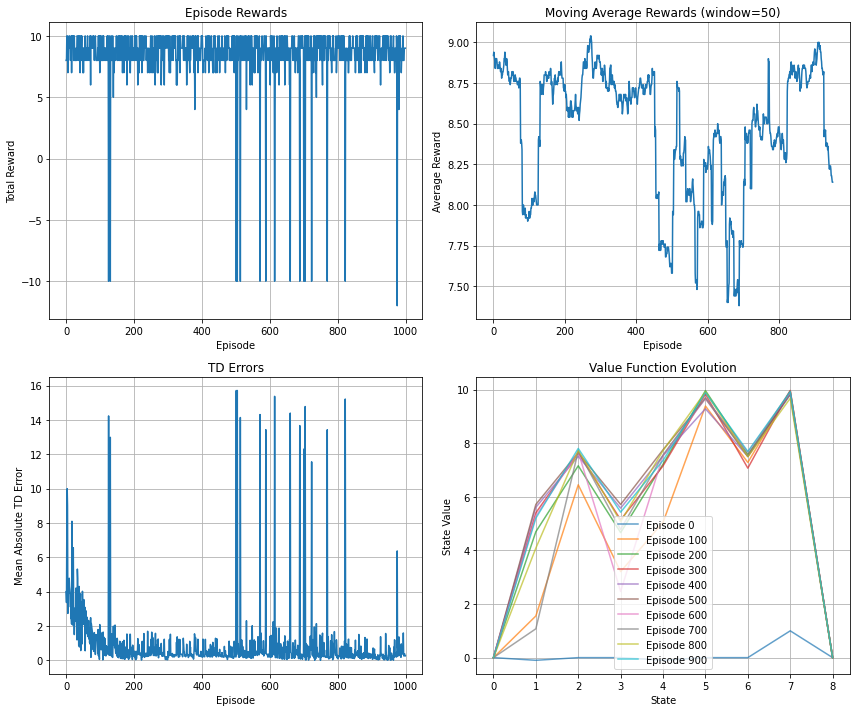

In [14]:
# Cell 10: Display final results and plot learning curves
env.print_grid(agent.V)

print("\nFinal Value Function:")
print("State -> Value")
for state in range(env.num_states):
    pos = env.id_to_state[state]
    terminal_info = " (TERMINAL)" if state in env.terminal_states else ""
    print(f"State {state} {pos}: {agent.V[state]:.3f}{terminal_info}")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Episode rewards
ax1.plot(episode_rewards)
ax1.set_title('Episode Rewards')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.grid(True)

# Moving average of rewards
window = 50
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    ax2.plot(moving_avg)
    ax2.set_title(f'Moving Average Rewards (window={window})')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Average Reward')
    ax2.grid(True)

# TD errors
ax3.plot(td_errors)
ax3.set_title('TD Errors')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Mean Absolute TD Error')
ax3.grid(True)

# Value function evolution
if len(value_history) > 1:
    for i, values in enumerate(value_history):
        ax4.plot(values, label=f'Episode {i*100}', alpha=0.7)
    ax4.set_title('Value Function Evolution')
    ax4.set_xlabel('State')
    ax4.set_ylabel('State Value')
    ax4.legend()
    ax4.grid(True)

plt.tight_layout()
plt.show()

Experimenting with different learning rates...

Testing alpha = 0.01
Final avg reward: 8.82

Testing alpha = 0.1
Final avg reward: 8.52

Testing alpha = 0.5
Final avg reward: 8.65

Testing alpha = 0.9
Final avg reward: 8.78


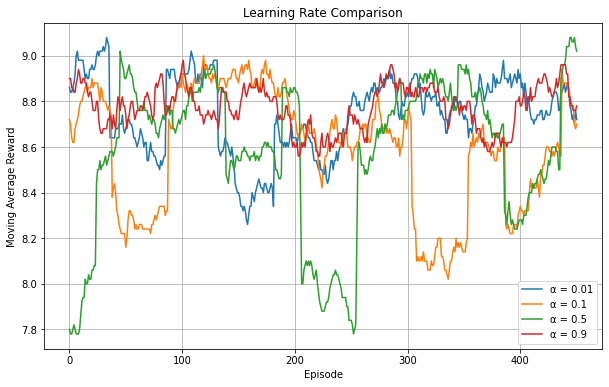

In [16]:
# Cell 11: Display final results and plot learning curves

print("Experimenting with different learning rates...")

alphas = [0.01, 0.1, 0.5, 0.9]
results = {}

for alpha in alphas:
    print(f"\nTesting alpha = {alpha}")
    test_agent = TD0Agent(env.num_states, env.num_actions, alpha=alpha, gamma=0.9, epsilon=0.1)
    rewards, _, _ = run_td0_learning(env, test_agent, episodes=500, verbose=False)
    results[alpha] = rewards
    print(f"Final avg reward: {np.mean(rewards[-100:]):.2f}")

# Plot comparison
plt.figure(figsize=(10, 6))
for alpha, rewards in results.items():
    window = 50
    moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    plt.plot(moving_avg, label=f'α = {alpha}')

plt.title('Learning Rate Comparison')
plt.xlabel('Episode')
plt.ylabel('Moving Average Reward')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Cell 12: Test learned policy
print("Testing learned policy...")

# Run a few test episodes with the trained agent
test_episodes = 5
agent.epsilon = 0  # Turn off exploration for testing

for episode in range(test_episodes):
    state = env.reset()
    episode_reward = 0
    path = [state]
    
    print(f"\nTest Episode {episode + 1}:")
    print(f"Start: State {state} {env.id_to_state[state]}")
    
    for step in range(20):
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        path.append(next_state)
        episode_reward += reward
        
        print(f"  Step {step + 1}: {env.actions[action]} -> State {next_state} {env.id_to_state[next_state]} (reward: {reward})")
        
        state = next_state
        if done:
            break
    
    print(f"  Total reward: {episode_reward}")
    print(f"  Path: {' -> '.join(map(str, path))}")

print("\nTD(0) Learning demonstration completed!")

Testing learned policy...

Test Episode 1:
Start: State 7 (2, 1)
  Step 1: right -> State 8 (2, 2) (reward: 10)
  Total reward: 10
  Path: 7 -> 8

Test Episode 2:
Start: State 7 (2, 1)
  Step 1: right -> State 8 (2, 2) (reward: 10)
  Total reward: 10
  Path: 7 -> 8

Test Episode 3:
Start: State 6 (2, 0)
  Step 1: right -> State 7 (2, 1) (reward: -1)
  Step 2: right -> State 8 (2, 2) (reward: 10)
  Total reward: 9
  Path: 6 -> 7 -> 8

Test Episode 4:
Start: State 6 (2, 0)
  Step 1: right -> State 7 (2, 1) (reward: -1)
  Step 2: right -> State 8 (2, 2) (reward: 10)
  Total reward: 9
  Path: 6 -> 7 -> 8

Test Episode 5:
Start: State 4 (1, 1)
  Step 1: down -> State 7 (2, 1) (reward: -1)
  Step 2: right -> State 8 (2, 2) (reward: 10)
  Total reward: 9
  Path: 4 -> 7 -> 8

TD(0) Learning demonstration completed!
